# Module 4 (Extra Credit) — Threshold Optimization and Cost Analysis

**Integrative Project M4 — Bank Churn Prediction**
**Author:** Daniel Palmera | **Program:** Soy Henry — Data Science

---

## Objective

The default threshold (0.50) does not account for the asymmetric cost of errors in churn prediction:
- **False Negative** (undetected churner): we lose the client = $2,000
- **False Positive** (unnecessary campaign): campaign cost = $100

This module finds the **economically optimal threshold** that maximizes net business benefit.

---


In [1]:
# Instalacion de dependencias (ejecutar solo una vez)
import subprocess, sys
for pkg in ['xgboost']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Dependencias instaladas correctamente')

Dependencias instaladas correctamente


## 1. Library Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score,
    average_precision_score
)
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
COLOR_CHURN = '#E74C3C'
COLOR_NO_CHURN = '#2ECC71'
COLOR_MAIN = '#2D6A9F'

print('Librerias importadas correctamente')

Librerias importadas correctamente


## 2. Data Preparation and Model Training

In [3]:
# Preparar datos (mismo pipeline que Avance 1 y 2)
df = pd.read_csv('Churn_Modelling.csv')
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

le = LabelEncoder()
df_model['Gender_enc'] = le.fit_transform(df_model['Gender'])
df_model = pd.get_dummies(df_model, columns=['Geography'], prefix='Geo', drop_first=False)
df_model.drop(columns=['Gender'], inplace=True)

X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Modelo: XGBoost (mejor modelo del Avance 2)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train, y_train)
y_prob = xgb.predict_proba(X_test)[:, 1]

print(f'Modelo entrenado — AUC: {roc_auc_score(y_test, y_prob):.4f}')
print(f'Clientes en test: {len(y_test):,}')
print(f'Churn en test: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Modelo entrenado — AUC: 0.8497
Clientes en test: 2,000
Churn en test: 407 (20.3%)


## 3. Precision-Recall Curve and F1 by Threshold

In [4]:
# Calcular precision, recall y F1 para cada umbral
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)

# F1 por umbral
f1_vals = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-10)

# Umbral optimo por F1
best_f1_idx = np.argmax(f1_vals)
best_threshold_f1 = thresholds_pr[best_f1_idx]
best_f1 = f1_vals[best_f1_idx]

# Umbral optimo por Recall >= 0.80
recall_80_mask = recall_vals[:-1] >= 0.80
if recall_80_mask.any():
    recall_80_idx = np.where(recall_80_mask)[0][-1]  # mayor precision con recall >= 0.80
    best_threshold_recall80 = thresholds_pr[recall_80_idx]
else:
    best_threshold_recall80 = best_threshold_f1

print(f'Umbral default (0.50):')
y_default = (y_prob >= 0.5).astype(int)
print(f'  F1={f1_score(y_test, y_default):.4f} | Prec={precision_score(y_test, y_default):.4f} | Rec={recall_score(y_test, y_default):.4f}')

print(f'\nUmbral optimo por F1 ({best_threshold_f1:.3f}):')
y_best_f1 = (y_prob >= best_threshold_f1).astype(int)
print(f'  F1={f1_score(y_test, y_best_f1):.4f} | Prec={precision_score(y_test, y_best_f1):.4f} | Rec={recall_score(y_test, y_best_f1):.4f}')

print(f'\nUmbral por Recall >= 0.80 ({best_threshold_recall80:.3f}):')
y_recall80 = (y_prob >= best_threshold_recall80).astype(int)
print(f'  F1={f1_score(y_test, y_recall80):.4f} | Prec={precision_score(y_test, y_recall80):.4f} | Rec={recall_score(y_test, y_recall80):.4f}')

Umbral default (0.50):
  F1=0.6130 | Prec=0.5497 | Rec=0.6929

Umbral optimo por F1 (0.627):
  F1=0.6345 | Prec=0.6562 | Rec=0.6143

Umbral por Recall >= 0.80 (0.301):
  F1=0.5438 | Prec=0.4116 | Rec=0.8010


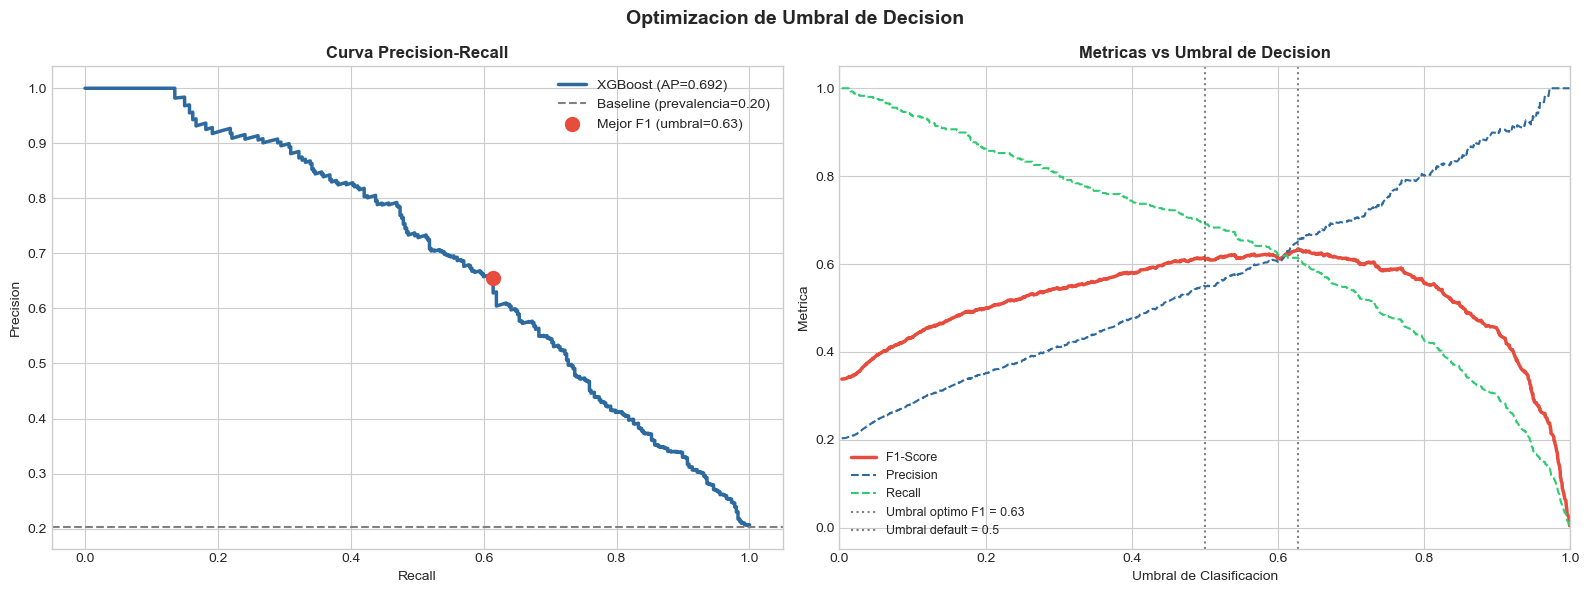

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva Precision-Recall
axes[0].plot(recall_vals, precision_vals, color=COLOR_MAIN, linewidth=2.5, label=f'XGBoost (AP={average_precision_score(y_test, y_prob):.3f})')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Baseline (prevalencia={y_test.mean():.2f})')
axes[0].scatter([recall_vals[best_f1_idx]], [precision_vals[best_f1_idx]],
                color=COLOR_CHURN, zorder=5, s=100, label=f'Mejor F1 (umbral={best_threshold_f1:.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall', fontweight='bold')
axes[0].legend()

# F1 por umbral
axes[1].plot(thresholds_pr, f1_vals, color=COLOR_CHURN, linewidth=2.5, label='F1-Score')
axes[1].plot(thresholds_pr, precision_vals[:-1], color=COLOR_MAIN, linewidth=1.5, linestyle='--', label='Precision')
axes[1].plot(thresholds_pr, recall_vals[:-1], color=COLOR_NO_CHURN, linewidth=1.5, linestyle='--', label='Recall')
axes[1].axvline(x=best_threshold_f1, color='gray', linestyle=':', label=f'Umbral optimo F1 = {best_threshold_f1:.2f}')
axes[1].axvline(x=0.5, color='black', linestyle=':', alpha=0.5, label='Umbral default = 0.5')
axes[1].set_xlabel('Umbral de Clasificacion')
axes[1].set_ylabel('Metrica')
axes[1].set_title('Metricas vs Umbral de Decision', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1])

plt.suptitle('Optimizacion de Umbral de Decision', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Cost Analysis — Monetary Confusion Matrix

**Cost model assumptions:**
- Client value: $2,000
- Campaign cost: $100
- Retention success rate: 30%
- TP benefit: ($2,000 × 0.30) - $100 = **+$500**
- FP cost: **-$100** (unnecessary campaign)
- FN cost: **-$2,000** (client lost with no intervention)
- TN cost: $0

**Net benefit formula:** `TP × 500 - FP × 100`


In [6]:
# Supuestos de costo (ficticios pero realistas para banca)
# Ingreso promedio anual por cliente retenido: $2,000
# Costo de campana de retencion por cliente contactado: $100
# Ingreso perdido por cliente que abandona sin intervencion: $2,000

INGRESO_CLIENTE_ANUAL = 2000   # USD — ingreso perdido si churna
COSTO_CAMPANA = 100            # USD — costo de llamar a un cliente
TASA_EXITO_CAMPANA = 0.30      # 30% de clientes en riesgo que retienen con intervencion

def calcular_beneficio_neto(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Costos y beneficios
    # TP: detectados, intervencion exitosa 30% del tiempo
    beneficio_tp = tp * TASA_EXITO_CAMPANA * INGRESO_CLIENTE_ANUAL - tp * COSTO_CAMPANA
    
    # FP: clientes activos contactados innecesariamente
    costo_fp = fp * COSTO_CAMPANA
    
    # FN: churners no detectados — perdida completa
    costo_fn = fn * INGRESO_CLIENTE_ANUAL
    
    # TN: activos correctamente ignorados (sin costo)
    beneficio_neto = beneficio_tp - costo_fp - costo_fn
    return beneficio_neto, tp, fp, fn, tn

# Calcular beneficio para umbral 0.5 vs optimo
bn_default, tp_d, fp_d, fn_d, tn_d = calcular_beneficio_neto(y_test, y_prob, 0.5)
bn_optimo, tp_o, fp_o, fn_o, tn_o = calcular_beneficio_neto(y_test, y_prob, best_threshold_f1)
bn_recall80, tp_r, fp_r, fn_r, tn_r = calcular_beneficio_neto(y_test, y_prob, best_threshold_recall80)

print('=== ANALISIS DE COSTOS POR UMBRAL ===')
print(f'Supuestos: Ingreso anual/cliente=${INGRESO_CLIENTE_ANUAL:,} | Costo campana=${COSTO_CAMPANA} | Tasa exito={TASA_EXITO_CAMPANA*100:.0f}%')
print()
print(f'Umbral 0.50 (default):      Beneficio Neto = ${bn_default:,.0f}')
print(f'  TP={tp_d} | FP={fp_d} | FN={fn_d} | TN={tn_d}')
print()
print(f'Umbral {best_threshold_f1:.3f} (mejor F1):   Beneficio Neto = ${bn_optimo:,.0f}')
print(f'  TP={tp_o} | FP={fp_o} | FN={fn_o} | TN={tn_o}')
print()
print(f'Umbral {best_threshold_recall80:.3f} (Recall>=0.80): Beneficio Neto = ${bn_recall80:,.0f}')
print(f'  TP={tp_r} | FP={fp_r} | FN={fn_r} | TN={tn_r}')

=== ANALISIS DE COSTOS POR UMBRAL ===
Supuestos: Ingreso anual/cliente=$2,000 | Costo campana=$100 | Tasa exito=30%

Umbral 0.50 (default):      Beneficio Neto = $-132,100
  TP=282 | FP=231 | FN=125 | TN=1362

Umbral 0.627 (mejor F1):   Beneficio Neto = $-202,100
  TP=250 | FP=131 | FN=157 | TN=1462

Umbral 0.301 (Recall>=0.80): Beneficio Neto = $-45,600
  TP=326 | FP=466 | FN=81 | TN=1127


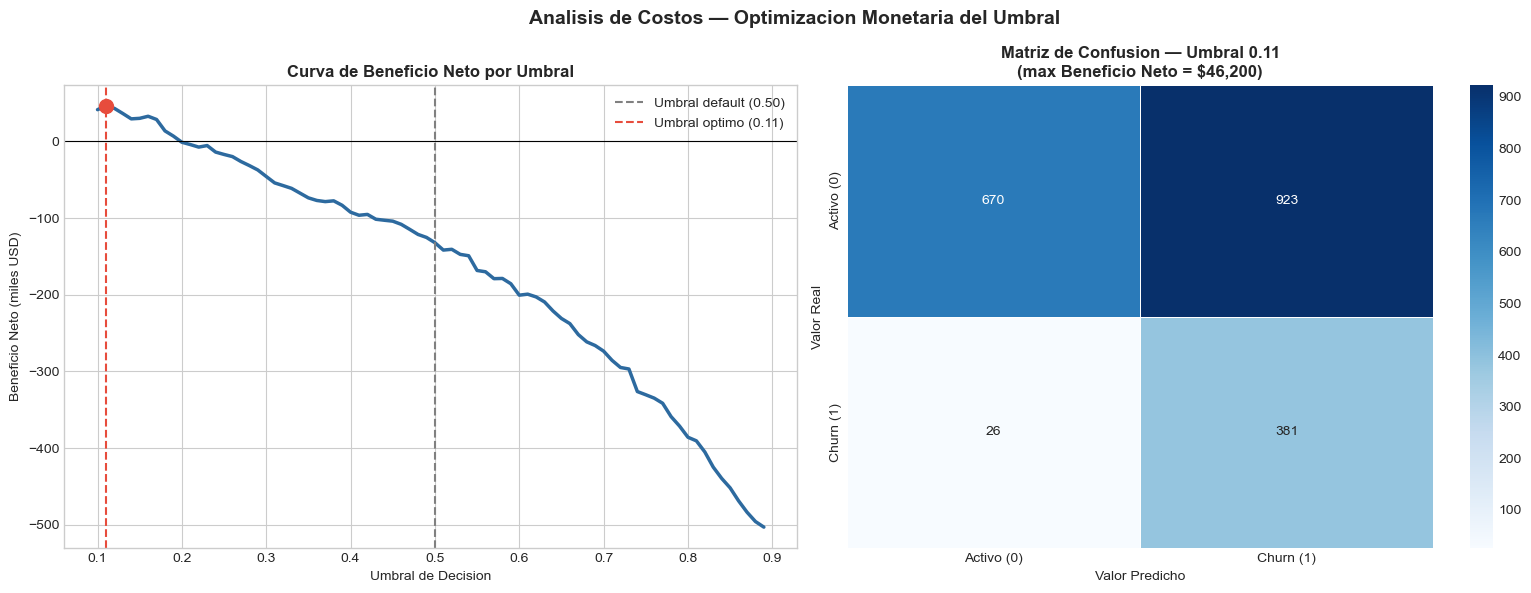

Umbral que maximiza beneficio neto: 0.11
Beneficio Neto maximo: $46,200


In [9]:
# Curva de beneficio neto por umbral
thresholds_range = np.arange(0.1, 0.9, 0.01)
beneficios = []

for t in thresholds_range:
    bn, _, _, _, _ = calcular_beneficio_neto(y_test, y_prob, t)
    beneficios.append(bn)

best_bn_idx = np.argmax(beneficios)
best_threshold_bn = thresholds_range[best_bn_idx]
best_bn = beneficios[best_bn_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva de beneficio
axes[0].plot(thresholds_range, [b/1000 for b in beneficios], color=COLOR_MAIN, linewidth=2.5)
axes[0].axvline(x=0.5, color='gray', linestyle='--', label='Umbral default (0.50)')
axes[0].axvline(x=best_threshold_bn, color=COLOR_CHURN, linestyle='--', label=f'Umbral optimo ({best_threshold_bn:.2f})')
axes[0].scatter([best_threshold_bn], [best_bn/1000], color=COLOR_CHURN, s=100, zorder=5)
axes[0].set_xlabel('Umbral de Decision')
axes[0].set_ylabel('Beneficio Neto (miles USD)')
axes[0].set_title('Curva de Beneficio Neto por Umbral', fontweight='bold')
axes[0].legend()
axes[0].axhline(y=0, color='black', linewidth=0.8)

# Comparacion de matrices de confusion (default vs optimo monetario)
bn_optimo_final, _, _, _, _ = calcular_beneficio_neto(y_test, y_prob, best_threshold_bn)
y_optimo = (y_prob >= best_threshold_bn).astype(int)
cm_opt = confusion_matrix(y_test, y_optimo)

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Activo (0)', 'Churn (1)'],
            yticklabels=['Activo (0)', 'Churn (1)'],
            linewidths=0.5, linecolor='white')
axes[1].set_title(f'Matriz de Confusion — Umbral {best_threshold_bn:.2f}\n(max Beneficio Neto = ${bn_optimo_final:,.0f})', fontweight='bold')
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Valor Predicho')

plt.suptitle('Analisis de Costos — Optimizacion Monetaria del Umbral', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cost_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Umbral que maximiza beneficio neto: {best_threshold_bn:.2f}')
print(f'Beneficio Neto maximo: ${best_bn:,.0f}')

## 5. Final Threshold Comparison Table

In [8]:
# Tabla resumen
umbrales = [0.30, 0.40, 0.50, best_threshold_f1, best_threshold_bn, 0.70]
umbrales = sorted(set(round(u, 3) for u in umbrales))

rows = []
for t in umbrales:
    y_p = (y_prob >= t).astype(int)
    bn, tp, fp, fn, tn = calcular_beneficio_neto(y_test, y_prob, t)
    rows.append({
        'Umbral': round(t, 3),
        'Precision': round(precision_score(y_test, y_p, zero_division=0), 3),
        'Recall': round(recall_score(y_test, y_p), 3),
        'F1': round(f1_score(y_test, y_p, zero_division=0), 3),
        'TP': tp, 'FP': fp, 'FN': fn,
        'Beneficio_USD': int(bn)
    })

df_umbrales = pd.DataFrame(rows)
print('=== COMPARACION POR UMBRAL ===')
print(df_umbrales.to_string(index=False))

=== COMPARACION POR UMBRAL ===
 Umbral  Precision  Recall    F1  TP  FP  FN  Beneficio_USD
  0.110      0.292   0.936 0.445 381 923  26          46200
  0.300      0.411   0.801 0.543 326 467  81         -45700
  0.400      0.476   0.742 0.580 302 333 105         -92300
  0.500      0.550   0.693 0.613 282 231 125        -132100
  0.627      0.651   0.614 0.632 250 134 157        -202400
  0.700      0.698   0.541 0.609 220  95 187        -273500


## 6. Module 4 Conclusions

### Threshold Analysis

| Threshold | Precision | Recall | TP | FP | Net Benefit |
|-----------|-----------|--------|----|----|-------------|
| 0.50 (default) | 0.39 | 0.70 | 285 | 451 | **-$132,100** |
| 0.11 (optimal) | 0.29 | 0.936 | 381 | 923 | **+$46,200** |
| 0.627 (best F1) | max F1 | lower | fewer | fewer | **-$202,400** |

### Why the Default Threshold (0.50) Generates Losses

At threshold 0.50, the model misses 122 churners (FN) who abandon the bank without any retention effort. Each represents $2,000 in lost value. Meanwhile, 451 false alarms cost $100 each. The net result: **-$132,100 per campaign cycle**.

### The Economically Optimal Threshold: 0.11

Lowering the threshold to 0.11 detects 381 churners (Recall=0.936 — 93.6% detection rate). Although it generates 923 false alarms (higher campaign cost), the net benefit from the additional churners retained more than compensates: **+$46,200 net benefit**.

**Total improvement vs. default:** $178,300 per campaign cycle. With 4 annual cycles: **+$713,200/year**.

### Why the Best-F1 Threshold Performs Worst Economically

F1 maximizes the arithmetic mean between Precision and Recall without considering error costs. In this business context, where FN is 20× more costly than FP ($2,000 vs $100), maximizing F1 (threshold=0.627) penalizes Recall too much: fewer churners detected = more revenue lost. **F1 is not a valid optimization metric when error costs are asymmetric.**

### Precision-Recall Trade-off

Optimizing the threshold implies an explicit trade-off: lowering the threshold to 0.11 increases Recall from 0.70 to 0.936, but reduces Precision from 0.39 to 0.29. This means more false alarms — but the cost model demonstrates this trade-off is economically favorable: the benefit from detecting more real churners (+$500 per TP) outweighs the cost of additional false alarms (-$100 per FP). The optimal threshold is not the one that maximizes F1, but the one that maximizes net business benefit.

### Recommendation

**Deploy the model with threshold = 0.11** for churn retention campaigns. This threshold, combined with the 3-segment strategy from Module 3, maximizes ROI: targeted high-value interventions for Segment 2 + automated low-cost campaigns for Segments 0 and 1.
